<a href="https://colab.research.google.com/github/awalinrizky/NLP-ulala/blob/main/UTS_NLP_Kelompok_Ulala.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. Data Collection**

##scraping data dari google play store

In [ ]:
#install google play scrapper
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 946.5 kB/s eta 0:00:00


In [ ]:
#import library
from google_play_scraper import reviews, Sort
import pandas as pd

In [ ]:
result, _ = reviews(
    'com.ss.android.ugc.trill',   # ID aplikasi tiktok
    lang='id',         # bahasa Indonesia
    country='id',      # negara Indonesia
    sort=Sort.NEWEST,  # urut terbaru
    count=20000        # jumlah data
)

In [ ]:
df = pd.DataFrame(result)
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,e6236310-f463-4461-b88c-68b0d79d2588,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,update nya lama 1jam dan di dalam nya juga ban...,1,0,44.6.4,2026-04-27 10:23:03,None,NaT,44.6.4
1,32db9223-0baa-4b80-9633-4946ca68f167,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,enak banyak feed komedi dan melihat konten kre...,5,0,43.7.3,2026-04-27 10:22:27,Hai! Terima kasih telah meluangkan waktu untuk...,2026-04-27 10:40:10,43.7.3
2,2fd7fed6-7362-4ede-b7bb-b1a920f002f5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apacoba kalo di buka apknya selalu stuck di lo...,1,0,44.9.3,2026-04-27 10:21:58,"Hai, maaf atas ketidaknyamanannya. Agar kami b...",2026-04-27 10:40:11,44.9.3
3,be377782-49f8-4b22-935c-8f3a2c2282a6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tik tok nih gimana si?? gw kan mau klaim koin,...",4,0,44.9.3,2026-04-27 10:21:14,"Hai, terima kasih atas umpan balikmu!\nKami pa...",2026-04-27 10:40:10,44.9.3
4,ab95d860-f1fe-44e6-9147-b94b2aabacc4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,None,2026-04-27 10:21:08,Hai! Terima kasih telah meluangkan waktu untuk...,2026-04-27 10:40:10,None


In [ ]:
# cek info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              20000 non-null  object        
 1   userName              20000 non-null  object        
 2   userImage             20000 non-null  object        
 3   content               20000 non-null  object        
 4   score                 20000 non-null  int64         
 5   thumbsUpCount         20000 non-null  int64         
 6   reviewCreatedVersion  13382 non-null  object        
 7   at                    20000 non-null  datetime64[ns]
 8   replyContent          16311 non-null  object        
 9   repliedAt             16311 non-null  datetime64[ns]
 10  appVersion            13382 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 1.7+ MB


In [ ]:
# cek missing value
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,6618
at,0
replyContent,3689
repliedAt,3689


In [ ]:
#Tambah data agar tidak terlalu jomplang

# 1. Scraping khusus rating 1
res_1, _ = reviews(
    'com.ss.android.ugc.trill',
    count=5000,
    filter_score_with=1,
    lang='id', country='id', sort=Sort.NEWEST
)

# 2. Scraping khusus rating 3
res_3, _ = reviews(
    'com.ss.android.ugc.trill',
    count=9000,
    filter_score_with=3,
    lang='id', country='id', sort=Sort.NEWEST
)

# 3. Gabungkan menjadi satu DataFrame
df_1 = pd.DataFrame(res_1)
df_3 = pd.DataFrame(res_3)
df_combined = pd.concat([df_1, df_3], ignore_index=True)

print(f"Total data terkumpul: {len(df_combined)}")
print(df_combined['score'].value_counts())

Total data terkumpul: 14000
score
3    9000
1    5000
Name: count, dtype: int64


In [ ]:
# Gabungkan dataframe lama (df) dengan data netral baru
df = pd.concat([df, df_combined], ignore_index=True)

# Cek distribusi score terbaru
print("Distribusi Score Terbaru:")
print(df['score'].value_counts())

Distribusi Score Terbaru:
score
5    10866
3    10375
1     9928
4     1633
2     1198
Name: count, dtype: int64


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
33995,False
33996,False
33997,False
33998,False


In [ ]:
df = df[['content','score']]
df.dropna(inplace=True)

In [ ]:
from google.colab import files

df.to_csv('tiktok_reviews_playstore.csv', index=False)
files.download('tiktok_reviews_playstore.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**2. Text Preprocessing**

##Import Data Hasil Scraping

In [ ]:
import pandas as pd

path = '1IMZz2ex21BmfhyfmtKFRaN9Dxr-aVXofS45LMtzmLnc'
url = f'https://docs.google.com/spreadsheets/d/{path}/export?format=csv'
df = pd.read_csv(url)

# 2. Cek apakah datanya sudah benar yang paling baru
print(f"Jumlah data: {len(df)}")
df

Jumlah data: 34000


,content,score
0,update nya lama 1jam dan di dalam nya juga ban...,1
1,enak banyak feed komedi dan melihat konten kre...,5
2,apacoba kalo di buka apknya selalu stuck di lo...,1
3,"tik tok nih gimana si?? gw kan mau klaim koin,...",4
4,mantap,5
...,...,...
33995,bagus malesnya ada sb doang cuih👎,3
33996,tolong lah buat aplikasi tiktok di perbaiki se...,3
33997,ga bisa aktif kan daftar putar🙁,3
33998,"Tiktok sekarang suka tinggalin jejak suara, ap...",3


##Cleaning Data

In [1]:
import re

slang_dict = {
    # Umum & Singkatan
    "gk": "tidak", "ga": "tidak", "nggak": "tidak", "tdk": "tidak", "nda": "tidak", "gak": "tidak", "kmrin": "kemarin", "bnyk":"banyak",
    "gbs": "tidak bisa", "gj": "tidak jelas", "tp": "tapi", "tpi": "tapi", "yg": "yang", "aja": "saja", "ktnya": "katanya", "enggak":"tidak",
    "bgt": "banget", "bngt": "banget", "bgtt": "banget", "dr": "dari", "udh": "sudah", "sdh": "sudah", "gue": "saya", "gpp": "tidak apa apa",
    "udah": "sudah", "hrs": "harus", "pdhl": "padahal", "krn": "karena", "dgn": "dengan", "sy": "saya", "ad": "ada", "gaada": "tidak ada",
    "gw": "saya", "gua": "saya", "lo": "kamu", "klo": "kalau", "kl": "kalau", "sm": "sama", "ama": "sama", "knp": "kenapa", "tmbh":"tambah",
    "knpa": "kenapa", " g":"tidak", "bngett":"banget", "baguss":"bagus", "acc":"disetujui", "aku":"saya", "yng":"yang", "hbis":"habis",
    "lg": "lagi", "lgi": "lagi", "bs": "bisa", "blm": "belum", "msh": "masih", "trs": "terus", "masak": "masa", "ak":"saya", "tlh":"telah",
    "ajah":"saja", "aja":"saja", "trus":"terus", "bet":"banget", "vn":"pesan suara", "kyk":"seperti", "g jelas":"tidak jelas", "utk":"untuk",
    "trims":"terima kasih", "ni":"ini", "seruu":"seru", "yangg":"yang", "adaa":"ada", "abis":"habis", "agk":"agak", "bs":"bisa",
    "bgs":"bagus", "bljr":"belajar", "baguszz":"bagus", "ori":"orisinal", "punyakh":"punya saya", "gada":"tidak ada", "tiba²":"tiba tiba",
    "bajak":"banyak", " do":"di", "apacoba":"apa coba", "apknya":"aplikasi nya", "gajelas":"tidak jelas", "debest":"terbaik", "bagu":"bagus",


    # Kata Kasar & Emosional (Penting untuk label Negative)
    "anjg": "anjing", "anjir": "anjing", "ajg": "anjing", "asu": "anjing", "jelek": "buruk", "jir":"anjing",
    "jancokk": "sialan", "jancok": "sialan", "dancok":"sialan","tolol": "bodoh", "gblk": "bodoh", "goblog": "bodoh", "bgst":"buruk",

    # Spesifik Aplikasi & Teknis
    "apl": "aplikasi", "apk": "aplikasi", "aplk": "aplikasi", "donlod": "unduh", "updet": "perbarui", "account":"akun", "download":"unduh",
    "ngleg": "lambat", "ngeleg": "lambat", "lemot": "lambat", "lalot": "lambat", "loding": "pemuatan", "leg":"lambat", "upload":"unggah",
    "bug": "kesalahan", "eror": "error", "vyp": "fyp", "vt": "video", "load": "pemuatan", "ngelek":"lambat", "post":"unggah",
    "update":"perbarui", "lag":"lambat", "ngepost":"mengunggah", "ngedownloadnya":"mengunduhnya", "abdet":"perbarui", "lemott":"lambat",
    "diupdate":"diperbarui", "epek":"efek", "pencet":"klik",
}

def clean_text(text):
    # 1. Lowercase & konversi ke string
    text = str(text).lower()

    # 2. Hapus URL, Mention (@), dan Hashtag (#)
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)

    # 3. Hapus angka
    text = re.sub(r'\d+', ' ', text)

    # 4. Hapus simbol/tanda baca (selain huruf dan spasi)
    text = re.sub(r'[^\w\s]', ' ', text)

    # 5. Normalisasi karakter berulang (misal: "loooove" -> "love")
    # Mengubah 3 atau lebih karakter berulang menjadi 1
    # Hanya hajar huruf vokal yang berulang (umumnya orang alay di vokal)
    text = re.sub(r'([aeiou])\1+', r'\1', text)
    # Dan khusus untuk konsonan, hapus jika berulang 3 kali atau lebih (seperti 'p' di mantappp)
    text = re.sub(r'([b-df-hj-np-tv-z])\1{2,}', r'\1', text)

    # 6. Pembersihan Spasi Berlebih & Tokenisasi ringan
    words = text.split()

    # 7. Penanganan Slang (Pastikan slang_dict sudah didefinisikan)
    # Gunakan .get() agar lebih clean
    words = [slang_dict.get(w, w) for w in words]

    # 8. Gabungkan kembali dan trim
    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df['clean_text'] = df['content'].apply(clean_text)

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
df.head(20)

,content,score,clean_text
0,update nya lama 1jam dan di dalam nya juga banyak orang stress,1,perbarui nya lama jam dan di dalam nya juga banyak orang stress
1,enak banyak feed komedi dan melihat konten kreator lainya dan saling ib&fb,5,enak banyak fed komedi dan melihat konten kreator lainya dan saling ib fb
2,apacoba kalo di buka apknya selalu stuck di loading loading gajelas,1,apa coba kalo di buka aplikasi nya selalu stuck di loading loading tidak jelas
3,"tik tok nih gimana si?? gw kan mau klaim koin, masa hari ini gk bisa di klaim koinnya??",4,tik tok nih gimana si saya kan mau klaim koin masa hari ini tidak bisa di klaim koinnya
4,mantap,5,mantap
5,mantep lah pokoknya.,5,mantep lah pokoknya
6,"tik, tik, tok. hehe Hha. platform media sosial. yg sangat bagus di jaman sekarang ini,. beda dgn yg lain. disini bisa jual barang dagang secara online. huft dan banyak lagi poko nya. sukses terus tiktok. and always berjaya.",5,tik tik tok hehe hha platform media sosial yang sangat bagus di jaman sekarang ini beda dengan yang lain disini bisa jual barang dagang secara online huft dan banyak lagi poko nya sukses terus tiktok and always berjaya
7,seruu,5,seru
8,tapi tolong di benerin bajak yang sesat,5,tapi tolong di benerin banyak yang sesat
9,"apalah gw udah upgrade ga ada stiker nya,jelek bnget,bug nya juga bnyak,tolong ya kalo upgrade tu yang lebih bagus, menginstal nya lama juga..",2,apalah saya sudah upgrade tidak ada stiker nya buruk bnget kesalahan nya juga bnyak tolong ya kalo upgrade tu yang lebih bagus menginstal nya lama juga


In [ ]:
print(f"Jumlah baris sebelum dibersihkan: {len(df)}")

Jumlah baris sebelum dibersihkan: 34000


In [ ]:
#menghapus baris yang kosong
# 1. Mengubah string yang hanya berisi spasi menjadi benar-benar kosong (NaN)
import numpy as np
df['clean_text'] = df['clean_text'].replace(r'^\s*$', np.nan, regex=True)

# 2. Menghapus baris yang memiliki NaN di kolom clean_text
df.dropna(subset=['clean_text'], inplace=True)

# 3. Opsional: Memastikan tidak ada string kosong "" yang tersisa
df = df[df['clean_text'].str.len() > 0]

# Reset index agar penomoran baris rapi kembali
df.reset_index(drop=True, inplace=True)

In [ ]:
print(f"Jumlah baris setelah dibersihkan: {len(df)}")

Jumlah baris setelah dibersihkan: 33775


In [ ]:
df.head(20)

,content,score,clean_text
0,update nya lama 1jam dan di dalam nya juga banyak orang stress,1,perbarui nya lama jam dan di dalam nya juga banyak orang stress
1,enak banyak feed komedi dan melihat konten kreator lainya dan saling ib&fb,5,enak banyak fed komedi dan melihat konten kreator lainya dan saling ib fb
2,apacoba kalo di buka apknya selalu stuck di loading loading gajelas,1,apa coba kalo di buka aplikasi nya selalu stuck di loading loading tidak jelas
3,"tik tok nih gimana si?? gw kan mau klaim koin, masa hari ini gk bisa di klaim koinnya??",4,tik tok nih gimana si saya kan mau klaim koin masa hari ini tidak bisa di klaim koinnya
4,mantap,5,mantap
5,mantep lah pokoknya.,5,mantep lah pokoknya
6,"tik, tik, tok. hehe Hha. platform media sosial. yg sangat bagus di jaman sekarang ini,. beda dgn yg lain. disini bisa jual barang dagang secara online. huft dan banyak lagi poko nya. sukses terus tiktok. and always berjaya.",5,tik tik tok hehe hha platform media sosial yang sangat bagus di jaman sekarang ini beda dengan yang lain disini bisa jual barang dagang secara online huft dan banyak lagi poko nya sukses terus tiktok and always berjaya
7,seruu,5,seru
8,tapi tolong di benerin bajak yang sesat,5,tapi tolong di benerin banyak yang sesat
9,"apalah gw udah upgrade ga ada stiker nya,jelek bnget,bug nya juga bnyak,tolong ya kalo upgrade tu yang lebih bagus, menginstal nya lama juga..",2,apalah saya sudah upgrade tidak ada stiker nya buruk bnget kesalahan nya juga bnyak tolong ya kalo upgrade tu yang lebih bagus menginstal nya lama juga


In [ ]:
from google.colab import files

df.to_csv('tiktok_reviews_playstore_cleaning.csv', index=False)
files.download('tiktok_reviews_playstore_cleaning.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Tokenization

In [2]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df['tokens'] = df['clean_text'].apply(word_tokenize)

In [ ]:
df.head(20)

,content,score,clean_text,tokens
0,update nya lama 1jam dan di dalam nya juga banyak orang stress,1,perbarui nya lama jam dan di dalam nya juga banyak orang stress,"[perbarui, nya, lama, jam, dan, di, dalam, nya, juga, banyak, orang, stress]"
1,enak banyak feed komedi dan melihat konten kreator lainya dan saling ib&fb,5,enak banyak fed komedi dan melihat konten kreator lainya dan saling ib fb,"[enak, banyak, fed, komedi, dan, melihat, konten, kreator, lainya, dan, saling, ib, fb]"
2,apacoba kalo di buka apknya selalu stuck di loading loading gajelas,1,apa coba kalo di buka aplikasi nya selalu stuck di loading loading tidak jelas,"[apa, coba, kalo, di, buka, aplikasi, nya, selalu, stuck, di, loading, loading, tidak, jelas]"
3,"tik tok nih gimana si?? gw kan mau klaim koin, masa hari ini gk bisa di klaim koinnya??",4,tik tok nih gimana si saya kan mau klaim koin masa hari ini tidak bisa di klaim koinnya,"[tik, tok, nih, gimana, si, saya, kan, mau, klaim, koin, masa, hari, ini, tidak, bisa, di, klaim, koinnya]"
4,mantap,5,mantap,[mantap]
5,mantep lah pokoknya.,5,mantep lah pokoknya,"[mantep, lah, pokoknya]"
6,"tik, tik, tok. hehe Hha. platform media sosial. yg sangat bagus di jaman sekarang ini,. beda dgn yg lain. disini bisa jual barang dagang secara online. huft dan banyak lagi poko nya. sukses terus tiktok. and always berjaya.",5,tik tik tok hehe hha platform media sosial yang sangat bagus di jaman sekarang ini beda dengan yang lain disini bisa jual barang dagang secara online huft dan banyak lagi poko nya sukses terus tiktok and always berjaya,"[tik, tik, tok, hehe, hha, platform, media, sosial, yang, sangat, bagus, di, jaman, sekarang, ini, beda, dengan, yang, lain, disini, bisa, jual, barang, dagang, secara, online, huft, dan, banyak, lagi, poko, nya, sukses, terus, tiktok, and, always, berjaya]"
7,seruu,5,seru,[seru]
8,tapi tolong di benerin bajak yang sesat,5,tapi tolong di benerin banyak yang sesat,"[tapi, tolong, di, benerin, banyak, yang, sesat]"
9,"apalah gw udah upgrade ga ada stiker nya,jelek bnget,bug nya juga bnyak,tolong ya kalo upgrade tu yang lebih bagus, menginstal nya lama juga..",2,apalah saya sudah upgrade tidak ada stiker nya buruk bnget kesalahan nya juga bnyak tolong ya kalo upgrade tu yang lebih bagus menginstal nya lama juga,"[apalah, saya, sudah, upgrade, tidak, ada, stiker, nya, buruk, bnget, kesalahan, nya, juga, bnyak, tolong, ya, kalo, upgrade, tu, yang, lebih, bagus, menginstal, nya, lama, juga]"


##Stopword removal

In [3]:
import pandas as pd

# 1. Ambil daftar stop words dari GitHub menggunakan Pandas
stopwords_url = "https://raw.githubusercontent.com/datascienceid/stopwords-bahasa-indonesia/master/stopwords_id_satya.txt"
# Mengonversi list dari csv menjadi 'set' untuk efisiensi
stop_words = set(pd.read_csv(stopwords_url, header=None)[0].tolist())

# 2. Daftar kata NEGASI yang HARUS DIHAPUS dari stop_words
# Agar model tetap bisa menangkap sentimen negatif
negasi = {'tidak', 'kurang', 'belum', 'bukan', 'jangan', 'tidaklah', 'tanpa','lumayan', "biasa", "saja"}
stop_words = stop_words - negasi

# 3. Daftar kata tambahan (Slang/Partikel)
custom_stop_words = {
    'nya', 'kak', 'bang', 'admin', 'si', 'nih', 'lah', 'kok', 'deh', 'tah',
    'dong', 'yah', 'mohon', 'tolong', 'halo', 'hai', 'terimakasih', 'kasih',
    'aplikasinya', 'udah', 'sudah', 'yg', 'yang',
    'aja', 'kali', 'cuma', 'cuman'
}

# Gabungkan semuanya
stop_words.update(custom_stop_words)

# Contoh pengecekan jumlah total stop words
print(f"Total stop words: {len(stop_words)}")

Total stop words: 368


In [4]:
# Fungsi untuk menghapus stopwords
def remove_custom_stopwords(tokens):
    # Pastikan tokens adalah list dan stop_words adalah set
    return [word for word in tokens if word not in stop_words]

In [ ]:
# Terapkan pada kolom dataframe
# Pastikan kolom 'tokens' berisi list of strings
df['tokens_final_stopwords'] = df['tokens'].apply(remove_custom_stopwords)

# Cek hasil perbandingan untuk verifikasi
print("=== Perbandingan Hasil Cleansing Stopwords ===")
index_contoh = 3
if index_contoh < len(df):
    print(f"Original (Index {index_contoh}):\n{df['tokens'].iloc[index_contoh]}")
    print("-" * 30)
    print(f"Cleaned  (Index {index_contoh}):\n{df['tokens_final_stopwords'].iloc[index_contoh]}")
else:
    print("Index tidak ditemukan dalam DataFrame.")

=== Perbandingan Hasil Cleansing Stopwords ===
Original (Index 3):
['tik', 'tok', 'nih', 'gimana', 'si', 'saya', 'kan', 'mau', 'klaim', 'koin', 'masa', 'hari', 'ini', 'tidak', 'bisa', 'di', 'klaim', 'koinnya']
------------------------------
Cleaned  (Index 3):
['tik', 'tok', 'gimana', 'klaim', 'koin', 'masa', 'hari', 'tidak', 'klaim', 'koinnya']


In [ ]:
df

,content,score,clean_text,tokens,tokens_final_stopwords
0,update nya lama 1jam dan di dalam nya juga banyak orang stress,1,perbarui nya lama jam dan di dalam nya juga banyak orang stress,"[perbarui, nya, lama, jam, dan, di, dalam, nya, juga, banyak, orang, stress]","[perbarui, jam, orang, stress]"
1,enak banyak feed komedi dan melihat konten kreator lainya dan saling ib&fb,5,enak banyak fed komedi dan melihat konten kreator lainya dan saling ib fb,"[enak, banyak, fed, komedi, dan, melihat, konten, kreator, lainya, dan, saling, ib, fb]","[enak, fed, komedi, melihat, konten, kreator, lainya, ib, fb]"
2,apacoba kalo di buka apknya selalu stuck di loading loading gajelas,1,apa coba kalo di buka aplikasi nya selalu stuck di loading loading tidak jelas,"[apa, coba, kalo, di, buka, aplikasi, nya, selalu, stuck, di, loading, loading, tidak, jelas]","[coba, kalo, buka, aplikasi, stuck, loading, loading, tidak, jelas]"
3,"tik tok nih gimana si?? gw kan mau klaim koin, masa hari ini gk bisa di klaim koinnya??",4,tik tok nih gimana si saya kan mau klaim koin masa hari ini tidak bisa di klaim koinnya,"[tik, tok, nih, gimana, si, saya, kan, mau, klaim, koin, masa, hari, ini, tidak, bisa, di, klaim, koinnya]","[tik, tok, gimana, klaim, koin, masa, hari, tidak, klaim, koinnya]"
4,mantap,5,mantap,[mantap],[mantap]
...,...,...,...,...,...
33770,bagus malesnya ada sb doang cuih👎,3,bagus malesnya ada sb doang cuih,"[bagus, malesnya, ada, sb, doang, cuih]","[bagus, malesnya, sb, doang, cuih]"
33771,tolong lah buat aplikasi tiktok di perbaiki sering banget kek gini buka titkok keluar sendiri ssh di buka hpus instal lgi selalu gini trs,3,tolong lah buat aplikasi tiktok di perbaiki sering banget kek gini buka titkok keluar sendiri ssh di buka hpus instal lagi selalu gini terus,"[tolong, lah, buat, aplikasi, tiktok, di, perbaiki, sering, banget, kek, gini, buka, titkok, keluar, sendiri, ssh, di, buka, hpus, instal, lagi, selalu, gini, terus]","[aplikasi, tiktok, perbaiki, banget, kek, gini, buka, titkok, keluar, ssh, buka, hpus, instal, gini, terus]"
33772,ga bisa aktif kan daftar putar🙁,3,tidak bisa aktif kan daftar putar,"[tidak, bisa, aktif, kan, daftar, putar]","[tidak, aktif, daftar, putar]"
33773,"Tiktok sekarang suka tinggalin jejak suara, aplikasi sudah di tutup semua tapi suara masih ada. Saya kira hp saya yg bermasalah, setelah ganti hp juga masih gitu. untuk menghentikan suara itu harus matiin hp.",3,tiktok sekarang suka tinggalin jejak suara aplikasi sudah di tutup semua tapi suara masih ada saya kira hp saya yang bermasalah setelah ganti hp juga masih gitu untuk menghentikan suara itu harus matin hp,"[tiktok, sekarang, suka, tinggalin, jejak, suara, aplikasi, sudah, di, tutup, semua, tapi, suara, masih, ada, saya, kira, hp, saya, yang, bermasalah, setelah, ganti, hp, juga, masih, gitu, untuk, menghentikan, suara, itu, harus, matin, hp]","[tiktok, suka, tinggalin, jejak, suara, aplikasi, tutup, suara, kira, hp, bermasalah, ganti, hp, gitu, untuk, menghentikan, suara, matin, hp]"


##Stemming / Lemmatization

In [5]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.6 MB/s eta 0:00:00


In [6]:
#fungsi steming
def stemming_process(tokens):
    # Gabungkan list kata menjadi satu string
    sentence = ' '.join(tokens)
    # Lakukan stemming
    stemmed_sentence = stemmer.stem(sentence)
    # Kembalikan menjadi list kata (token)
    return stemmed_sentence.split()

In [ ]:
# Menerapkan pada kolom tokens_final
df['stemmed_tokens'] = df['tokens_final_stopwords'].apply(stemming_process)

In [ ]:
df

,content,score,clean_text,tokens,tokens_final_stopwords,stemmed_tokens
0,update nya lama 1jam dan di dalam nya juga banyak orang stress,1,perbarui nya lama jam dan di dalam nya juga banyak orang stress,"[perbarui, nya, lama, jam, dan, di, dalam, nya, juga, banyak, orang, stress]","[perbarui, jam, orang, stress]","[baru, jam, orang, stress]"
1,enak banyak feed komedi dan melihat konten kreator lainya dan saling ib&fb,5,enak banyak fed komedi dan melihat konten kreator lainya dan saling ib fb,"[enak, banyak, fed, komedi, dan, melihat, konten, kreator, lainya, dan, saling, ib, fb]","[enak, fed, komedi, melihat, konten, kreator, lainya, ib, fb]","[enak, fed, komedi, lihat, konten, kreator, lai, ib, fb]"
2,apacoba kalo di buka apknya selalu stuck di loading loading gajelas,1,apa coba kalo di buka aplikasi nya selalu stuck di loading loading tidak jelas,"[apa, coba, kalo, di, buka, aplikasi, nya, selalu, stuck, di, loading, loading, tidak, jelas]","[coba, kalo, buka, aplikasi, stuck, loading, loading, tidak, jelas]","[coba, kalo, buka, aplikasi, stuck, loading, loading, tidak, jelas]"
3,"tik tok nih gimana si?? gw kan mau klaim koin, masa hari ini gk bisa di klaim koinnya??",4,tik tok nih gimana si saya kan mau klaim koin masa hari ini tidak bisa di klaim koinnya,"[tik, tok, nih, gimana, si, saya, kan, mau, klaim, koin, masa, hari, ini, tidak, bisa, di, klaim, koinnya]","[tik, tok, gimana, klaim, koin, masa, hari, tidak, klaim, koinnya]","[tik, tok, gimana, klaim, koin, masa, hari, tidak, klaim, koin]"
4,mantap,5,mantap,[mantap],[mantap],[mantap]
...,...,...,...,...,...,...
33770,bagus malesnya ada sb doang cuih👎,3,bagus malesnya ada sb doang cuih,"[bagus, malesnya, ada, sb, doang, cuih]","[bagus, malesnya, sb, doang, cuih]","[bagus, malesnya, sb, doang, cuih]"
33771,tolong lah buat aplikasi tiktok di perbaiki sering banget kek gini buka titkok keluar sendiri ssh di buka hpus instal lgi selalu gini trs,3,tolong lah buat aplikasi tiktok di perbaiki sering banget kek gini buka titkok keluar sendiri ssh di buka hpus instal lagi selalu gini terus,"[tolong, lah, buat, aplikasi, tiktok, di, perbaiki, sering, banget, kek, gini, buka, titkok, keluar, sendiri, ssh, di, buka, hpus, instal, lagi, selalu, gini, terus]","[aplikasi, tiktok, perbaiki, banget, kek, gini, buka, titkok, keluar, ssh, buka, hpus, instal, gini, terus]","[aplikasi, tiktok, baik, banget, kek, gin, buka, titkok, keluar, ssh, buka, hpus, instal, gin, terus]"
33772,ga bisa aktif kan daftar putar🙁,3,tidak bisa aktif kan daftar putar,"[tidak, bisa, aktif, kan, daftar, putar]","[tidak, aktif, daftar, putar]","[tidak, aktif, daftar, putar]"
33773,"Tiktok sekarang suka tinggalin jejak suara, aplikasi sudah di tutup semua tapi suara masih ada. Saya kira hp saya yg bermasalah, setelah ganti hp juga masih gitu. untuk menghentikan suara itu harus matiin hp.",3,tiktok sekarang suka tinggalin jejak suara aplikasi sudah di tutup semua tapi suara masih ada saya kira hp saya yang bermasalah setelah ganti hp juga masih gitu untuk menghentikan suara itu harus matin hp,"[tiktok, sekarang, suka, tinggalin, jejak, suara, aplikasi, sudah, di, tutup, semua, tapi, suara, masih, ada, saya, kira, hp, saya, yang, bermasalah, setelah, ganti, hp, juga, masih, gitu, untuk, menghentikan, suara, itu, harus, matin, hp]","[tiktok, suka, tinggalin, jejak, suara, aplikasi, tutup, suara, kira, hp, bermasalah, ganti, hp, gitu, untuk, menghentikan, suara, matin, hp]","[tiktok, suka, tinggalin, jejak, suara, aplikasi, tutup, suara, kira, hp, masalah, ganti, hp, gitu, untuk, henti, suara, matin, hp]"


In [ ]:
df.to_csv('hasil_preprocesing.csv', index=False)
files.download('hasil_preprocesing.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**3. Feature Extraction**

##Import Data Hasil Preprocesing

In [7]:
import pandas as pd

path = '1RqUbe1C2g54T-6KrVNqlj6_ZijFVNq62iil27Kz-CHI'
url = f'https://docs.google.com/spreadsheets/d/{path}/export?format=csv'
df = pd.read_csv(url)

# 2. Cek apakah datanya sudah benar yang paling baru
print(f"Jumlah data: {len(df)}")
df

Jumlah data: 33775


,content,score,clean_text,tokens,tokens_final_stopwords,stemmed_tokens
0,update nya lama 1jam dan di dalam nya juga ban...,1,perbarui nya lama jam dan di dalam nya juga ba...,"['perbarui', 'nya', 'lama', 'jam', 'dan', 'di'...","['perbarui', 'jam', 'orang', 'stress']","['baru', 'jam', 'orang', 'stress']"
1,enak banyak feed komedi dan melihat konten kre...,5,enak banyak fed komedi dan melihat konten krea...,"['enak', 'banyak', 'fed', 'komedi', 'dan', 'me...","['enak', 'fed', 'komedi', 'melihat', 'konten',...","['enak', 'fed', 'komedi', 'lihat', 'konten', '..."
2,apacoba kalo di buka apknya selalu stuck di lo...,1,apa coba kalo di buka aplikasi nya selalu stuc...,"['apa', 'coba', 'kalo', 'di', 'buka', 'aplikas...","['coba', 'kalo', 'buka', 'aplikasi', 'stuck', ...","['coba', 'kalo', 'buka', 'aplikasi', 'stuck', ..."
3,"tik tok nih gimana si?? gw kan mau klaim koin,...",4,tik tok nih gimana si saya kan mau klaim koin ...,"['tik', 'tok', 'nih', 'gimana', 'si', 'saya', ...","['tik', 'tok', 'gimana', 'klaim', 'koin', 'mas...","['tik', 'tok', 'gimana', 'klaim', 'koin', 'mas..."
4,mantap,5,mantap,['mantap'],['mantap'],['mantap']
...,...,...,...,...,...,...
33770,bagus malesnya ada sb doang cuih👎,3,bagus malesnya ada sb doang cuih,"['bagus', 'malesnya', 'ada', 'sb', 'doang', 'c...","['bagus', 'malesnya', 'sb', 'doang', 'cuih']","['bagus', 'malesnya', 'sb', 'doang', 'cuih']"
33771,tolong lah buat aplikasi tiktok di perbaiki se...,3,tolong lah buat aplikasi tiktok di perbaiki se...,"['tolong', 'lah', 'buat', 'aplikasi', 'tiktok'...","['aplikasi', 'tiktok', 'perbaiki', 'banget', '...","['aplikasi', 'tiktok', 'baik', 'banget', 'kek'..."
33772,ga bisa aktif kan daftar putar🙁,3,tidak bisa aktif kan daftar putar,"['tidak', 'bisa', 'aktif', 'kan', 'daftar', 'p...","['tidak', 'aktif', 'daftar', 'putar']","['tidak', 'aktif', 'daftar', 'putar']"
33773,"Tiktok sekarang suka tinggalin jejak suara, ap...",3,tiktok sekarang suka tinggalin jejak suara apl...,"['tiktok', 'sekarang', 'suka', 'tinggalin', 'j...","['tiktok', 'suka', 'tinggalin', 'jejak', 'suar...","['tiktok', 'suka', 'tinggalin', 'jejak', 'suar..."


##BOW

In [8]:
#Melabeli rating dengan sentimen positive, neutral, negative
def label_sentiment(score):
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

df['label'] = df['score'].apply(label_sentiment)

In [9]:
# Cek distribusi label
print(df['label'].value_counts())

label
positive    12319
negative    11115
neutral     10341
Name: count, dtype: int64


In [10]:
import ast

df['stemmed_tokens'] = df['stemmed_tokens'].apply(ast.literal_eval)

In [11]:
df['final_text'] = df['stemmed_tokens'].apply(lambda x: ' '.join(x))

In [12]:
print(type(df['stemmed_tokens'].iloc[0]))
print(df['stemmed_tokens'].iloc[0])

<class 'list'>
['baru', 'jam', 'orang', 'stress']


In [13]:
df.head()

,content,score,clean_text,tokens,tokens_final_stopwords,stemmed_tokens,label,final_text
0,update nya lama 1jam dan di dalam nya juga ban...,1,perbarui nya lama jam dan di dalam nya juga ba...,"['perbarui', 'nya', 'lama', 'jam', 'dan', 'di'...","['perbarui', 'jam', 'orang', 'stress']","[baru, jam, orang, stress]",negative,baru jam orang stress
1,enak banyak feed komedi dan melihat konten kre...,5,enak banyak fed komedi dan melihat konten krea...,"['enak', 'banyak', 'fed', 'komedi', 'dan', 'me...","['enak', 'fed', 'komedi', 'melihat', 'konten',...","[enak, fed, komedi, lihat, konten, kreator, la...",positive,enak fed komedi lihat konten kreator lai ib fb
2,apacoba kalo di buka apknya selalu stuck di lo...,1,apa coba kalo di buka aplikasi nya selalu stuc...,"['apa', 'coba', 'kalo', 'di', 'buka', 'aplikas...","['coba', 'kalo', 'buka', 'aplikasi', 'stuck', ...","[coba, kalo, buka, aplikasi, stuck, loading, l...",negative,coba kalo buka aplikasi stuck loading loading ...
3,"tik tok nih gimana si?? gw kan mau klaim koin,...",4,tik tok nih gimana si saya kan mau klaim koin ...,"['tik', 'tok', 'nih', 'gimana', 'si', 'saya', ...","['tik', 'tok', 'gimana', 'klaim', 'koin', 'mas...","[tik, tok, gimana, klaim, koin, masa, hari, ti...",positive,tik tok gimana klaim koin masa hari tidak klai...
4,mantap,5,mantap,['mantap'],['mantap'],[mantap],positive,mantap


In [14]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Inisialisasi CountVectorizer (BOW)
bow_vectorizer = CountVectorizer()

# 2. Transformasi data teks (final_text) menjadi matrix frekuensi kata
X_bow = bow_vectorizer.fit_transform(df['final_text'])

# 3. Mengambil label target
y = df['label']

# Cek informasi hasil extraction
print(f"=== Metadata Bag of Words ===")
print(f"Jumlah dokumen (baris): {X_bow.shape[0]}")
print(f"Jumlah kosakata unik (fitur): {X_bow.shape[1]}")
print(f"\nContoh 10 kata pertama dalam kosakata:\n{bow_vectorizer.get_feature_names_out()[:10]}")

=== Metadata Bag of Words ===
Jumlah dokumen (baris): 33775
Jumlah kosakata unik (fitur): 11307

Contoh 10 kata pertama dalam kosakata:
['aba' 'abad' 'abadi' 'abai' 'abal' 'abc' 'abdate' 'abdetnyh' 'abdett'
 'abet']


##TF-IDF

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Inisialisasi TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))

# 2. Transformasi data teks (final_text) menjadi matrix bobot TF-IDF
X_tfidf = tfidf_vectorizer.fit_transform(df['final_text'])

# 3. Cek informasi hasil extraction
print(f"=== Metadata TF-IDF ===")
print(f"Jumlah dokumen (baris): {X_tfidf.shape[0]}")
print(f"Jumlah kosakata unik (fitur): {X_tfidf.shape[1]}")

# Melihat contoh bobot pada satu review (misal review pertama)
first_vector = X_tfidf[0]
df_tfidf_check = pd.DataFrame(first_vector.T.todense(),
                              index=tfidf_vectorizer.get_feature_names_out(),
                              columns=["tfidf_weight"])
print("\nContoh bobot kata pada review pertama:")
print(df_tfidf_check[df_tfidf_check['tfidf_weight'] > 0])

=== Metadata TF-IDF ===
Jumlah dokumen (baris): 33775
Jumlah kosakata unik (fitur): 94994

Contoh bobot kata pada review pertama:
              tfidf_weight
baru              0.160139
baru jam          0.470381
jam               0.296993
jam orang         0.483857
orang             0.210116
orang stress      0.483857
stress            0.390522


##Word Embedding **FastText**

In [16]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.6 MB/s eta 0:00:00


In [17]:
from gensim.models import FastText
import numpy as np

# 1. Menyiapkan data: FastText membutuhkan input berupa list of tokens
sentences = df['stemmed_tokens'].tolist()

# 2. Melatih Model FastText
# vector_size: dimensi vektor 100
# window: jarak maksimum antara kata saat ini dan kata yang diprediksi
# min_count: abaikan kata dengan total frekuensi lebih rendah dari ini
model_ft = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4, sg=1)

# 3. Fungsi untuk mengubah satu review (list of tokens) menjadi satu vektor rata-rata
# Karena FastText menghasilkan vektor per kata, kita harus merata-ratakannya agar jadi satu vektor per review
def get_sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# 4. Transformasi seluruh data menjadi matrix fitur
X_fasttext = np.array([get_sentence_vector(t, model_ft) for t in sentences])

print(f"=== Metadata FastText ===")
print(f"Bentuk Matrix Fitur: {X_fasttext.shape}")
print(f"Contoh 5 nilai pertama dari vektor review pertama:\n{X_fasttext[0][:5]}")

=== Metadata FastText ===
Bentuk Matrix Fitur: (33775, 100)
Contoh 5 nilai pertama dari vektor review pertama:
[-0.31318235 -0.44054183  0.47535872  0.02156377  0.42734438]


#**4. Modeling**

##Naive Bayes

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

# List untuk menyimpan hasil perbandingan akhir
model_results = []

def train_eval_nb_final(X, y, feature_name):
    # 1. Split Data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Pre-processing khusus fitur FastText (Vektor kontinu)
    # MultinomialNB membutuhkan nilai non-negatif
    if feature_name == "FastText":
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # 3. Menangani Imbalance Data dengan SMOTE
    # Ini akan membuat data sintetis untuk kelas 'negative' dan 'neutral' agar seimbang dengan 'positive'
    print(f"\n[INFO] Menyeimbangkan data untuk {feature_name}...")
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print(f"Distribusi kelas sebelum SMOTE: {Counter(y_train)}")
    print(f"Distribusi kelas sesudah SMOTE: {Counter(y_train_res)}")

    # 4. Training Model Multinomial Naive Bayes
    # Kita gunakan alpha=0.1 untuk meningkatkan sensitivitas terhadap kata yang jarang muncul
    nb_model = MultinomialNB(alpha=0.1)
    nb_model.fit(X_train_res, y_train_res)

    # 5. Prediksi & Evaluasi
    y_pred = nb_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== Evaluasi Naive Bayes + SMOTE ({feature_name}) ===")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

    return {"Feature": feature_name, "Accuracy": acc}

# Eksekusi untuk ketiga jenis ekstraksi fitur yang sudah kamu buat
results_bow = train_eval_nb_final(X_bow, df['label'], "Bag of Words")
results_tfidf = train_eval_nb_final(X_tfidf, df['label'], "TF-IDF")
results_ft = train_eval_nb_final(X_fasttext, df['label'], "FastText")

# Menyimpan hasil ke dalam list perbandingan
model_results.extend([results_bow, results_tfidf, results_ft])


[INFO] Menyeimbangkan data untuk Bag of Words...
Distribusi kelas sebelum SMOTE: Counter({'positive': 9865, 'negative': 8900, 'neutral': 8255})
Distribusi kelas sesudah SMOTE: Counter({'negative': 9865, 'positive': 9865, 'neutral': 9865})

=== Evaluasi Naive Bayes + SMOTE (Bag of Words) ===
Accuracy: 0.6598

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.61      0.64      2215
     neutral       0.54      0.58      0.56      2086
    positive       0.76      0.77      0.77      2454

    accuracy                           0.66      6755
   macro avg       0.66      0.65      0.65      6755
weighted avg       0.66      0.66      0.66      6755

------------------------------------------------------------

[INFO] Menyeimbangkan data untuk TF-IDF...
Distribusi kelas sebelum SMOTE: Counter({'positive': 9865, 'negative': 8900, 'neutral': 8255})
Distribusi kelas sesudah SMOTE: Counter({'negative': 9865, 'positive': 9865, 'neutral

##Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# List untuk menyimpan hasil perbandingan Logistic Regression
logreg_results = []

def train_eval_logreg(X, y, feature_name):
    # 1. Split Data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Training Logistic Regression
    # class_weight='balanced' secara otomatis memberikan bobot lebih pada kelas minoritas (neutral/negative)
    # max_iter=1000 agar model punya cukup waktu untuk konvergen (mencapai hasil optimal)
    lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr_model.fit(X_train, y_train)

    # 3. Prediksi
    y_pred = lr_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"=== Evaluasi Logistic Regression ({feature_name}) ===")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

    return {"Feature": feature_name, "Accuracy": acc}

# Eksekusi untuk ketiga jenis fitur
res_lr_bow = train_eval_logreg(X_bow, df['label'], "Bag of Words")
res_lr_tfidf = train_eval_logreg(X_tfidf, df['label'], "TF-IDF")
res_lr_ft = train_eval_logreg(X_fasttext, df['label'], "FastText")

# Simpan hasil untuk bagian perbandingan nanti
logreg_results.extend([res_lr_bow, res_lr_tfidf, res_lr_ft])

=== Evaluasi Logistic Regression (Bag of Words) ===
Accuracy: 0.6897

Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.69      0.69      2215
     neutral       0.60      0.55      0.57      2086
    positive       0.76      0.81      0.78      2454

    accuracy                           0.69      6755
   macro avg       0.68      0.68      0.68      6755
weighted avg       0.69      0.69      0.69      6755

------------------------------------------------------------
=== Evaluasi Logistic Regression (TF-IDF) ===
Accuracy: 0.7315

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.78      0.75      2215
     neutral       0.64      0.61      0.63      2086
    positive       0.82      0.78      0.80      2454

    accuracy                           0.73      6755
   macro avg       0.73      0.73      0.73      6755
weighted avg       0.73      0.73      0.73      675

##SVM

In [20]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# List untuk menyimpan hasil perbandingan SVM
svm_results = []

def train_eval_svm(X, y, feature_name):
    # 1. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Training SVM (LinearSVC biasanya lebih cepat untuk data teks besar)
    # class_weight='balanced' untuk menangani data tidak seimbang
    svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
    svm_model.fit(X_train, y_train)

    # 3. Prediksi
    y_pred = svm_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"=== Evaluasi SVM ({feature_name}) ===")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

    return {"Feature": feature_name, "Accuracy": acc}

# Eksekusi untuk ketiga jenis fitur
res_svm_bow = train_eval_svm(X_bow, df['label'], "Bag of Words")
res_svm_tfidf = train_eval_svm(X_tfidf, df['label'], "TF-IDF")
res_svm_ft = train_eval_svm(X_fasttext, df['label'], "FastText")

# Simpan hasil
svm_results.extend([res_svm_bow, res_svm_tfidf, res_svm_ft])

=== Evaluasi SVM (Bag of Words) ===
Accuracy: 0.6959

Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.72      0.70      2215
     neutral       0.62      0.54      0.58      2086
    positive       0.75      0.81      0.78      2454

    accuracy                           0.70      6755
   macro avg       0.69      0.69      0.69      6755
weighted avg       0.69      0.70      0.69      6755

------------------------------------------------------------
=== Evaluasi SVM (TF-IDF) ===
Accuracy: 0.7460

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.83      0.79      2215
     neutral       0.68      0.60      0.64      2086
    positive       0.80      0.79      0.79      2454

    accuracy                           0.75      6755
   macro avg       0.74      0.74      0.74      6755
weighted avg       0.74      0.75      0.74      6755

-----------------------------

##Visualiasi

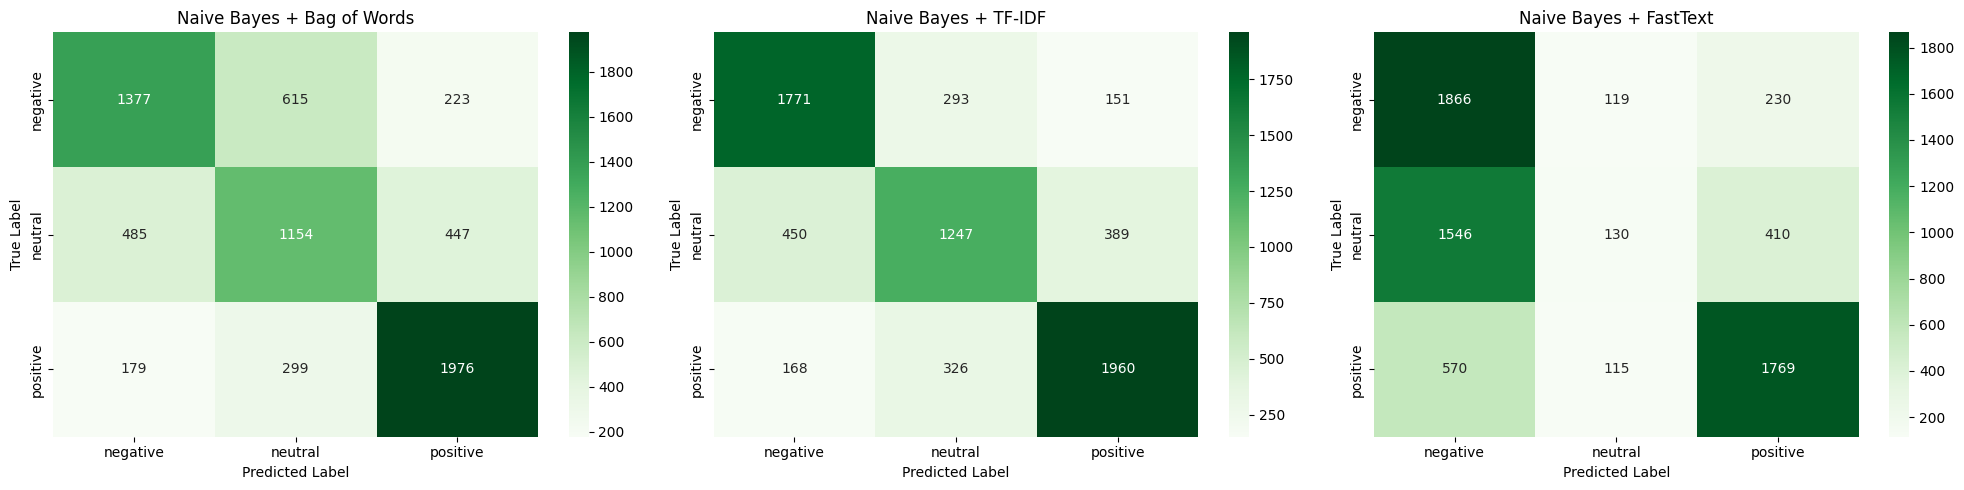

In [21]:
#NAIVE BAYES

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

# Konfigurasi Fitur
features = [
    (X_bow, "Bag of Words"),
    (X_tfidf, "TF-IDF"),
    (X_fasttext, "FastText")
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = ['negative', 'neutral', 'positive']

for i, (X, title) in enumerate(features):
    # Split data 80:20
    X_train, X_test, y_train, y_test = train_test_split(X, df['label'], test_size=0.2, random_state=42)

    # Preprocessing khusus FastText untuk Naive Bayes
    if title == "FastText":
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Model Naive Bayes dengan alpha 0.1
    model = MultinomialNB(alpha=0.1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i],
                xticklabels=labels, yticklabels=labels)
    axes[i].set_title(f'Naive Bayes + {title}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

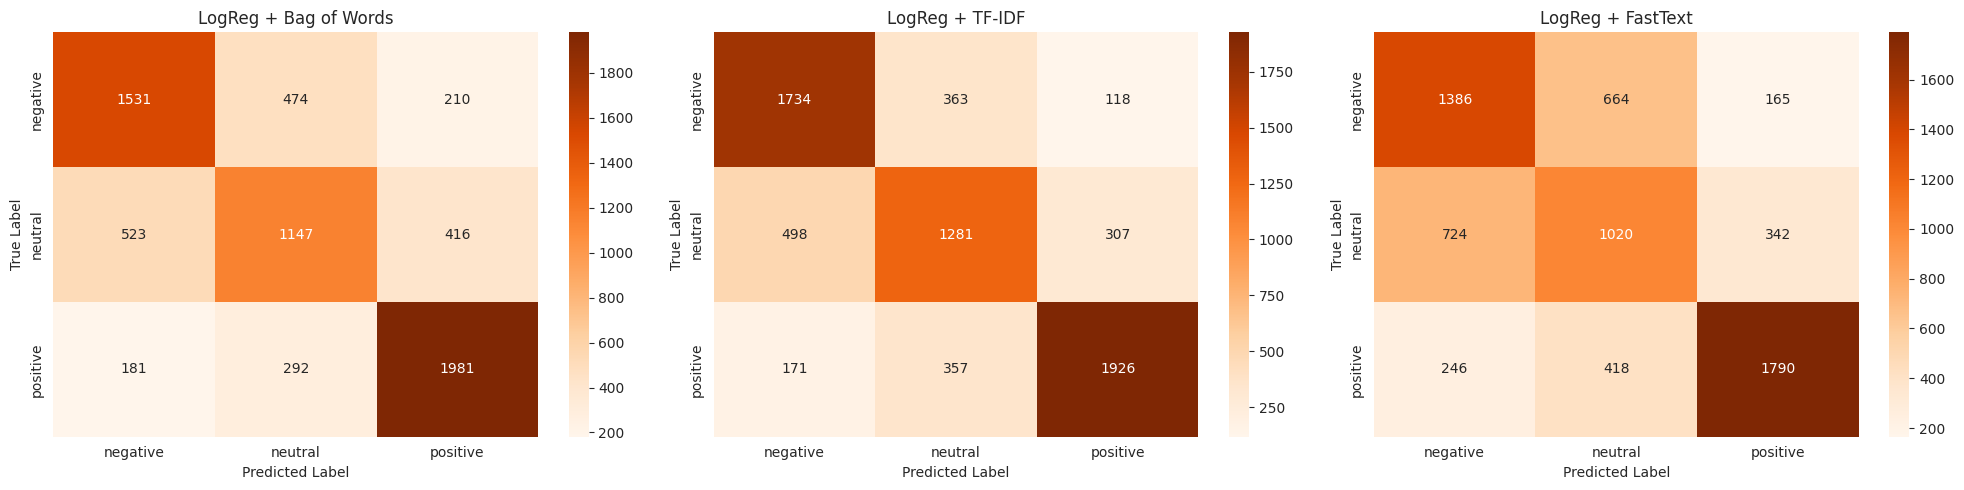

In [ ]:
#LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (X, title) in enumerate(features):
    X_train, X_test, y_train, y_test = train_test_split(X, df['label'], test_size=0.2, random_state=42)

    # Model Logistic Regression
    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i],
                xticklabels=labels, yticklabels=labels)
    axes[i].set_title(f'LogReg + {title}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

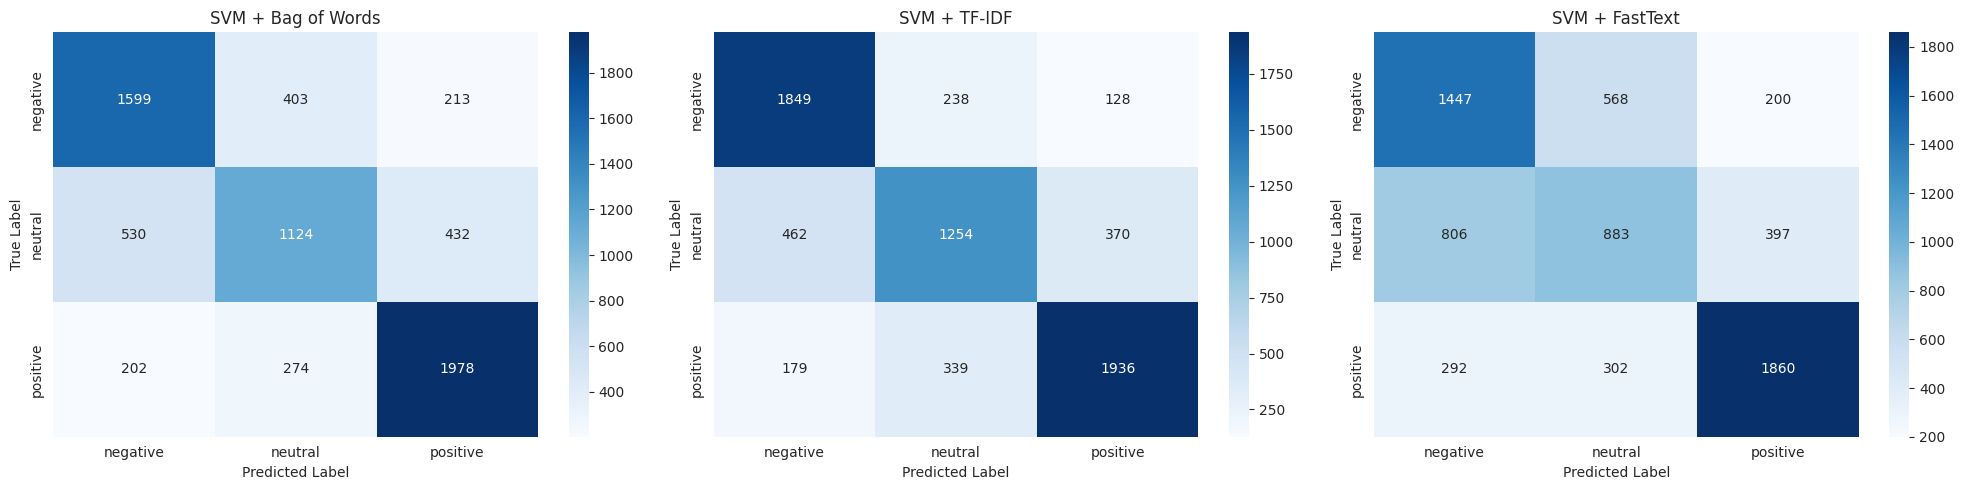

In [ ]:
#SVM

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# 1. Persiapkan data dan list fitur
features = [
    (X_bow, "Bag of Words"),
    (X_tfidf, "TF-IDF"),
    (X_fasttext, "FastText")
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = ['negative', 'neutral', 'positive']

for i, (X, title) in enumerate(features):
    # Split data (sesuai dengan random_state di notebook kalian)
    X_train, X_test, y_train, y_test = train_test_split(X, df['label'], test_size=0.2, random_state=42)

    # Inisialisasi dan latih model SVM
    model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    # Buat Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    # Visualisasi
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=labels, yticklabels=labels)
    axes[i].set_title(f'SVM + {title}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

##Download Model

In [22]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# --- 1. Siapkan Data Split untuk TF-IDF (Fitur Terbaik) ---
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_tfidf, df['label'], test_size=0.2, random_state=42
)

print("⏳ Sedang melatih ulang model final...")

# --- 2. Latih SVM (Pemenang Utama: 74.60%) ---
svm_model_tfidf = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_model_tfidf.fit(X_train_final, y_train_final)

# --- 3. Latih Naive Bayes (Runner Up: 73.47%) ---
nb_model_tfidf = MultinomialNB(alpha=0.1)
nb_model_tfidf.fit(X_train_final, y_train_final)

# --- 4. Latih Logistic Regression (73.15%) ---
lr_final_tfidf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_final_tfidf.fit(X_train_final, y_train_final)

print("✅ Semua variabel model (svm_model_tfidf, nb_model_tfidf, lr_final_tfidf) siap digunakan!")

⏳ Sedang melatih ulang model final...
✅ Semua variabel model (svm_model_tfidf, nb_model_tfidf, lr_final_tfidf) siap digunakan!


In [ ]:
import joblib
from google.colab import files

# Simpan ke file .pkl
joblib.dump(svm_model_tfidf, 'best_svm_tfidf_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer_ngram.pkl')
joblib.dump(nb_model_tfidf, 'nb_tfidf_model.pkl')
joblib.dump(lr_final_tfidf, 'logreg_tfidf_model.pkl')

print("--- Mendownload file model ---")
files.download('best_svm_tfidf_model.pkl')
files.download('tfidf_vectorizer_ngram.pkl')
files.download('nb_tfidf_model.pkl')
files.download('logreg_tfidf_model.pkl')

--- Mendownload file model ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**5. Comparison Model**

##Perbandingan Tiap Model dengan TF-IDF vs dengan Embedding

In [24]:
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. Persiapkan data split untuk setiap ekstraksi fitur yang sudah dibuat sebelumnya
# Menggunakan random_state=42 agar konsisten dengan evaluasi sebelumnya
# --- BOW ---
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(X_bow, df['label'], test_size=0.2, random_state=42)

# --- TF-IDF ---
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, df['label'], test_size=0.2, random_state=42)

# --- FastText ---
X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(X_fasttext, df['label'], test_size=0.2, random_state=42)

# 2. Siapkan MinMaxScaler khusus untuk Naive Bayes + FastText
# (Karena MultinomialNB membutuhkan nilai non-negatif)
scaler = MinMaxScaler()
X_train_ft_scaled = scaler.fit_transform(X_train_ft)
X_test_ft_scaled = scaler.transform(X_test_ft)

# 3. Inisialisasi algoritma dengan parameter yang sesuai di notebook
model_nb = MultinomialNB(alpha=0.1)
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)

# 4. Fungsi untuk run model dan hitung metrik lengkap
def hitung_metrik(model, X_train_data, X_test_data, y_train_data, y_test_data, nama_model, nama_fitur):
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)
    return {
        "Feature Extraction": nama_fitur,
        "Model": nama_model,
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision": precision_score(y_test_data, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test_data, y_pred, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test_data, y_pred, average='weighted', zero_division=0)
    }

hasil_lengkap = []

# --- A. PERBANDINGAN PADA FITUR: Bag of Words (BOW) ---
hasil_lengkap.append(hitung_metrik(model_nb, X_train_bow, X_test_bow, y_train_bow, y_test_bow, "Naive Bayes", "Bag of Words"))
hasil_lengkap.append(hitung_metrik(model_lr, X_train_bow, X_test_bow, y_train_bow, y_test_bow, "Logistic Regression", "Bag of Words"))
hasil_lengkap.append(hitung_metrik(model_svm, X_train_bow, X_test_bow, y_train_bow, y_test_bow, "SVM (LinearSVC)", "Bag of Words"))

# --- B. PERBANDINGAN PADA FITUR: TF-IDF ---
hasil_lengkap.append(hitung_metrik(model_nb, X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf, "Naive Bayes", "TF-IDF"))
hasil_lengkap.append(hitung_metrik(model_lr, X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf, "Logistic Regression", "TF-IDF"))
hasil_lengkap.append(hitung_metrik(model_svm, X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf, "SVM (LinearSVC)", "TF-IDF"))

# --- C. PERBANDINGAN PADA FITUR: FastText (Embedding) ---
# Gunakan data scaled khusus untuk Naive Bayes
hasil_lengkap.append(hitung_metrik(model_nb, X_train_ft_scaled, X_test_ft_scaled, y_train_ft, y_test_ft, "Naive Bayes", "FastText"))
hasil_lengkap.append(hitung_metrik(model_lr, X_train_ft, X_test_ft, y_train_ft, y_test_ft, "Logistic Regression", "FastText"))
hasil_lengkap.append(hitung_metrik(model_svm, X_train_ft, X_test_ft, y_train_ft, y_test_ft, "SVM (LinearSVC)", "FastText"))

# 5. Tampilkan Tabel Hasil Perbandingan Akhir
df_perbandingan_final = pd.DataFrame(hasil_lengkap)
display(df_perbandingan_final.sort_values(by="Feature Extraction", ascending=False))

,Feature Extraction,Model,Accuracy,Precision,Recall,F1-score
3,TF-IDF,Naive Bayes,0.736936,0.734266,0.736936,0.734609
4,TF-IDF,Logistic Regression,0.731458,0.731922,0.731458,0.731064
5,TF-IDF,SVM (LinearSVC),0.745966,0.743944,0.745966,0.743225
6,FastText,Naive Bayes,0.557365,0.530720,0.557365,0.494548
7,FastText,Logistic Regression,0.624870,0.631426,0.624870,0.627441
8,FastText,SVM (LinearSVC),0.622946,0.619888,0.622946,0.619525
0,Bag of Words,Naive Bayes,0.667209,0.664849,0.667209,0.665271
1,Bag of Words,Logistic Regression,0.689711,0.685828,0.689711,0.687173
2,Bag of Words,SVM (LinearSVC),0.695929,0.691614,0.695929,0.692342


##Visualisasi perbandingan

=== Tabel Perbandingan Akurasi Otomatis ===
Feature              Bag of Words  FastText    TF-IDF
Model                                                
Logistic Regression      0.689711  0.624870  0.731458
Naive Bayes              0.659808  0.566543  0.734715
SVM                      0.695929  0.622946  0.745966


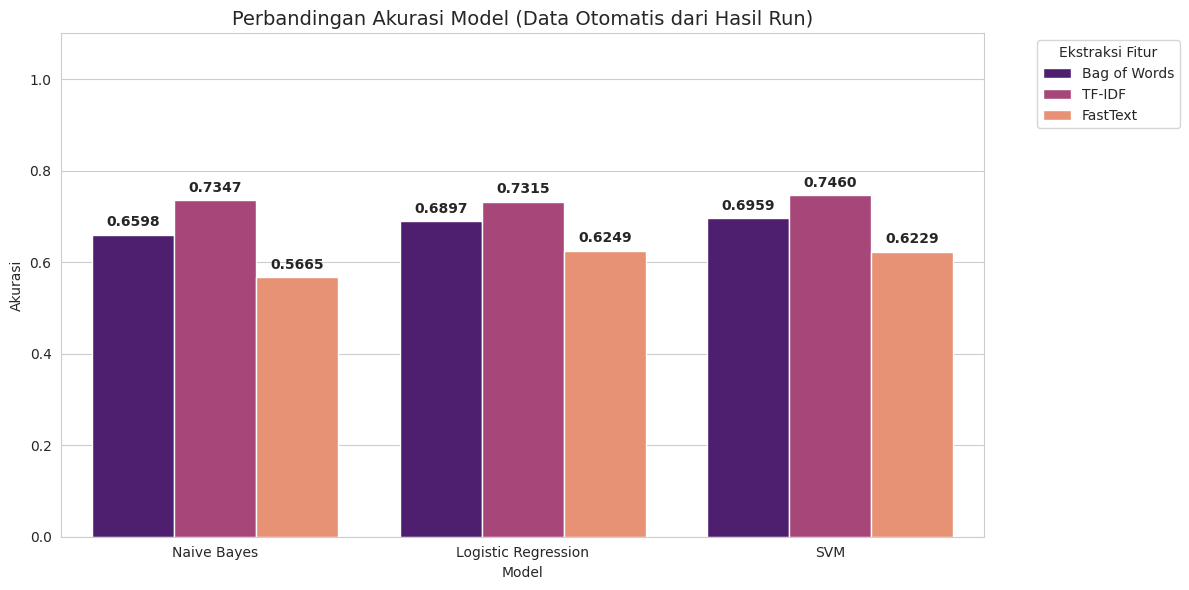

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengumpulkan hasil secara otomatis dari list yang sudah ada
# Menambahkan kolom 'Model' agar bisa dibedakan saat digabung
df_nb = pd.DataFrame(model_results)
df_nb['Model'] = 'Naive Bayes'

df_lr = pd.DataFrame(logreg_results)
df_lr['Model'] = 'Logistic Regression'

df_svm = pd.DataFrame(svm_results)
df_svm['Model'] = 'SVM'

# 2. Menggabungkan semua dataframe menjadi satu
df_compare = pd.concat([df_nb, df_lr, df_svm], ignore_index=True)

# 3. Menampilkan Tabel Perbandingan
print("=== Tabel Perbandingan Akurasi Otomatis ===")
# Pivot agar tampilannya rapi (Model sebagai baris, Feature sebagai kolom)
tabel_pivot = df_compare.pivot(index='Model', columns='Feature', values='Accuracy')
print(tabel_pivot)

# 4. Visualisasi Grafik Batang
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Model', y='Accuracy', hue='Feature', data=df_compare, palette='magma')

# Menambahkan label angka akurasi di atas batang secara otomatis
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.4f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.title('Perbandingan Akurasi Model (Data Otomatis dari Hasil Run)', fontsize=14)
plt.ylim(0, 1.1)
plt.ylabel('Akurasi')
plt.legend(title='Ekstraksi Fitur', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##Insight Tambahan

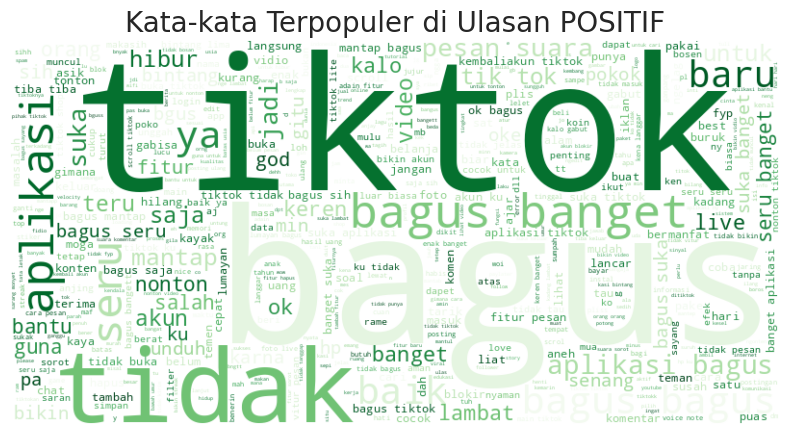

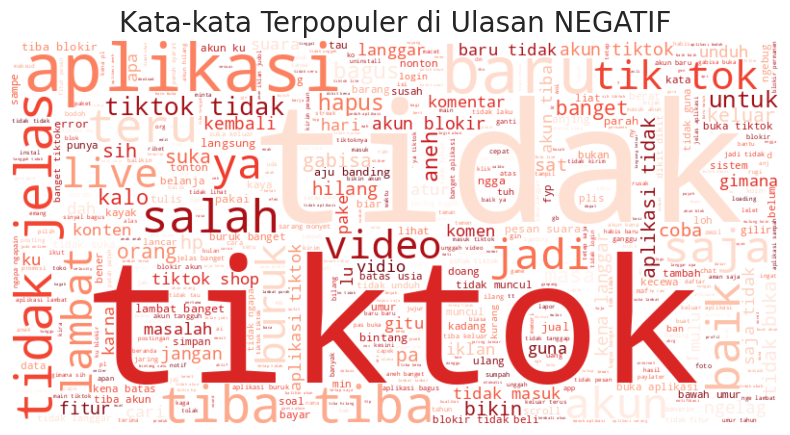

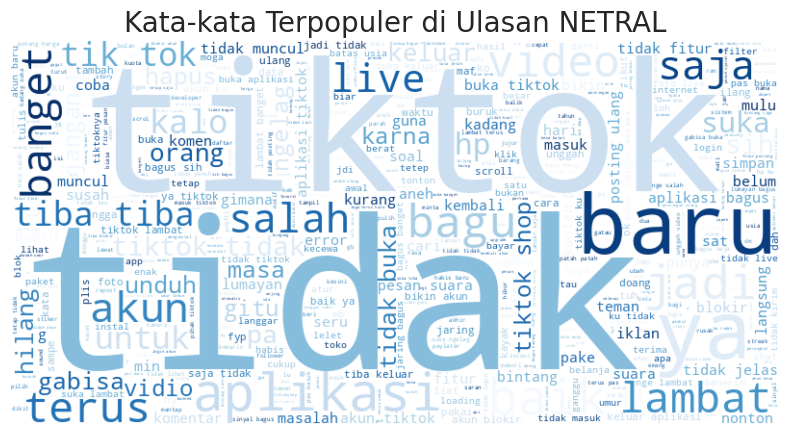

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def show_wordcloud(sentiment_label, title, color):
    # Menggabungkan semua teks berdasarkan label tertentu
    text = ' '.join(df[df['label'] == sentiment_label]['stemmed_tokens'].apply(lambda x: ' '.join(x)))

    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap=color,
                          max_words=500).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

# Menampilkan WordCloud untuk tiap kategori
show_wordcloud('positive', 'Kata-kata Terpopuler di Ulasan POSITIF', 'Greens')
show_wordcloud('negative', 'Kata-kata Terpopuler di Ulasan NEGATIF', 'Reds')
show_wordcloud('neutral', 'Kata-kata Terpopuler di Ulasan NETRAL', 'Blues')

#**6. Simple Deployment Menggunakan Gradio**

In [26]:
import gradio as gr
from nltk.tokenize import word_tokenize

def predict_sentiment_final(review_text):
    if not review_text.strip():
        return "Silakan masukkan teks review..."

    # 1. Tahap Cleaning & Slang Handling (Menggunakan fungsi yang telah dibuat)
    # Membersihkan simbol, angka, dan memperbaiki kata alay/slang
    text_cleaned = clean_text(review_text)

    # 2. Tahap Tokenization (Menggunakan fungsi yang telah dibuat)
    # Memecah kalimat menjadi list kata
    tokens = word_tokenize(text_cleaned)

    # 3. Tahap Stopword Removal (Menggunakan fungsi yang telah dibuat)
    # Menghapus kata yang tidak penting, tetapi tetap mempertahankan negasi
    tokens_no_stop = remove_custom_stopwords(tokens)

    # 4. Tahap Stemming (Menggunakan fungsi yang telah dibuat)
    # Mengembalikan kata ke bentuk dasarnya
    tokens_stemmed = stemming_process(tokens_no_stop)

    # 5. Konversi kembali ke String
    # TF-IDF Vectorizer membutuhkan input berupa string tunggal
    final_input_text = ' '.join(tokens_stemmed)

    # 6. Transformasi ke TF-IDF (Menggunakan vectorizer)
    text_vector = tfidf_vectorizer.transform([final_input_text])

    # 7. Prediksi dengan Model Terbaik
    prediction = svm_model_tfidf.predict(text_vector)[0]

    labels = {
        'positive': "😊 POSITIF",
        'negative': "😡 NEGATIF",
        'neutral': "😐 NETRAL"
    }
    return labels.get(prediction, prediction)

# Menyiapkan Interface Gradio
demo = gr.Interface(
    fn=predict_sentiment_final,
    inputs=gr.Textbox(lines=3, label="Input Review TikTok"),
    outputs=gr.Label(label="Hasil Analisis (SVM + TF-IDF)"),
    title="🚀 Analisis Review Aplikasi (Play Store) - TikTok Sentiment Analysis - Kelompok Ulala",
    description="Analisis sentimen ulasan pengguna TikTok menggunakan SVM + TF-IDF N-gram (Akurasi: 74.60%)",
    examples=[
        ["Aplikasi tiktoknya bagus banget saya suka!"],
        ["Jelek banget, Aplikasi tidak berguna!"],
        ["Lumayan lah cukup membantu"],
        ["Biasa saja aplikasinya"],
    ],
    theme="Monochrome"
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://95d68f2e83960e064d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
